# DataCo Smart Supply Chain Analytics: End-to-End Business Intelligence Project

An end-to-end data analytics project on DataCo Global's supply chain operations, 
covering order fulfillment, shipping performance, customer segmentation, and 
profitability across global markets. This analysis uses Python for data cleaning 
and exploration, SQL for structured querying, and Power BI for dashboarding.

| Project Information | Details |
|--------------------|---------|
| **Dataset** | DataCo Smart Supply Chain for Big Data Analysis |
| **Rows** | 180,519 |
| **Columns** | 53 |
| **Industry** | Supply Chain & Logistics |
| **Tools** | Excel, Python (Pandas, NumPy, Matplotlib, Seaborn), SQL, Power BI |

##  Project Overview

This project analyzes the **DataCo Smart Supply Chain Dataset**, a real-world business dataset containing over **180,000 supply chain transactions** across customers, products, orders, shipping, and logistics operations.

The analysis focuses on understanding sales performance, customer behavior, shipping efficiency, product profitability, and regional business trends. Using Python for data analysis, the project transforms raw business data into actionable insights that can support better operational and strategic decision-making.

The project follows a complete analytics workflow, including data validation, exploratory data analysis (EDA), feature engineering, business insights, and recommendations.

##  Business Problem

Modern supply chain organizations generate large volumes of transactional data from customers, products, orders, and logistics operations. Without effective analysis, it becomes difficult to identify delivery bottlenecks, profitable products, high-value customers, and operational inefficiencies.

This project aims to analyze the DataCo Smart Supply Chain dataset to uncover trends in sales, profitability, customer behavior, shipping performance, and regional operations. The insights generated can help businesses optimize logistics, improve customer satisfaction, and support data-driven decision-making.

## Objectives

- Analyze sales and profit performance.
- Evaluate customer purchasing behavior.
- Identify top-performing products and categories.
- Analyze regional and market-wise sales trends.
- Assess shipping performance and delivery efficiency.
- Detect operational bottlenecks and business opportunities.
- Generate actionable business recommendations.

##  Project Workflow

```
Raw Dataset
      │
      ▼
Data Validation
      │
      ▼
Exploratory Data Analysis
      │
      ▼
Feature Engineering
      │
      ▼
Business Insights
      │
      ▼
Business Recommendations
      │
      ▼
Executive Summary
```

In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    for filename in filenames:
        print("   ", filename)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/shashwatwork
/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis
    tokenized_access_logs.csv
    DataCoSupplyChainDataset.csv
    DescriptionDataCoSupplyChain.csv


In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "shashwatwork/dataco-smart-supply-chain-for-big-data-analysis"
)

print(path)

/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis


In [3]:
# ==============================
# Import Required Libraries
# ==============================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# Plot Style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
df = pd.read_csv(
    "/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DataCoSupplyChainDataset.csv",
    encoding="latin1"
)

print(df.shape)
df.head()

(180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.00,2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.00,2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.94,0.07,179252,327.75,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.50,0.09,179251,327.75,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


##  Data Understanding

Before performing any analysis, it is essential to understand the structure and characteristics of the dataset. This section provides an overview of the dataset, including its dimensions, column names, data types, sample records, and statistical summaries. These checks help validate the data and build a strong foundation for further analysis.

In [5]:
# ==============================
# Dataset Shape
# ==============================

rows, cols = df.shape

print(f"Number of Rows    : {rows:,}")
print(f"Number of Columns : {cols}")

Number of Rows    : 180,519
Number of Columns : 53


In [6]:
# Display first five records
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.00,2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.00,2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.94,0.07,179252,327.75,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.50,0.09,179251,327.75,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [7]:
# Display last five records
df.tail()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
180514,CASH,4,4,40.00,399.98,Shipping on time,0,45,Fishing,Brooklyn,EE. UU.,XXXXXXXXX,Maria,1005,Peterson,XXXXXXXXX,Home Office,NY,1322 Broad Glade,11207.00,7,Fan Shop,40.64,-73.94,Pacific Asia,Shanghái,China,1005,1/16/2016 3:40,26043,1004,0.00,0.00,65177,399.98,0.10,1,399.98,399.98,40.00,Eastern Asia,Shanghái,CLOSED,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.98,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.77,395.98,Late delivery,1,45,Fishing,Bakersfield,EE. UU.,XXXXXXXXX,Ronald,9141,Clark,XXXXXXXXX,Corporate,CA,7330 Broad Apple Moor,93304.00,7,Fan Shop,35.36,-119.02,Pacific Asia,Hirakata,Japón,9141,1/16/2016 1:34,26037,1004,4.00,0.01,65161,399.98,-1.55,1,399.98,395.98,-613.77,Eastern Asia,Osaka,COMPLETE,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.98,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.11,391.98,Late delivery,1,45,Fishing,Bristol,EE. UU.,XXXXXXXXX,John,291,Smith,XXXXXXXXX,Corporate,CT,97 Burning Landing,6010.00,7,Fan Shop,41.63,-72.97,Pacific Asia,Adelaide,Australia,291,1/15/2016 21:00,26024,1004,8.00,0.02,65129,399.98,0.36,1,399.98,391.98,141.11,Oceania,Australia del Sur,PENDING,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.98,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.23,387.98,Advance shipping,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Mary,2813,Smith,XXXXXXXXX,Consumer,PR,2585 Silent Autumn Landing,725.00,7,Fan Shop,18.21,-66.37,Pacific Asia,Adelaide,Australia,2813,1/15/2016 20:18,26022,1004,12.00,0.03,65126,399.98,0.48,1,399.98,387.98,186.23,Oceania,Australia del Sur,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.98,0,1/18/2016 20:18,Standard Class
180518,PAYMENT,4,4,168.95,383.98,Shipping on time,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Andrea,7547,Ortega,XXXXXXXXX,Consumer,PR,697 Little Meadow,725.00,7,Fan Shop,18.29,-66.37,Pacific Asia,Nagercoil,India,7547,1/15/2016 18:54,26018,1004,16.00,0.04,65113,399.98,0.44,1,399.98,383.98,168.95,South Asia,Tamil Nadu,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.98,0,1/19/2016 18:54,Standard Class


In [8]:
# Display random sample
df.sample(5, random_state=42)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
80120,TRANSFER,5,4,11.09,175.99,Late delivery,1,48,Water Sports,Caguas,Puerto Rico,XXXXXXXXX,Zachary,6109,Tate,XXXXXXXXX,Consumer,PR,8916 Round Zephyr Ridge,725.00,7,Fan Shop,18.20,-66.37,USCA,Los Angeles,Estados Unidos,6109,4/1/2016 21:05,31299,1073,24.00,0.12,78239,199.99,0.06,1,199.99,175.99,11.09,West of USA,California,PROCESSING,90036.00,1073,48,NaN,http://images.acmesports.sports/Pelican+Sunstr...,Pelican Sunstream 100 Kayak,199.99,0,4/6/2016 21:05,Standard Class
19670,PAYMENT,2,1,9.80,245.00,Late delivery,1,24,Women's Apparel,Florissant,EE. UU.,XXXXXXXXX,Gary,12041,Oneal,XXXXXXXXX,Consumer,MO,372 Sunny Arbor,63033.00,5,Golf,38.81,-90.30,LATAM,Tegucigalpa,Honduras,12041,6/9/2017 18:43,61023,502,5.00,0.02,152658,50.00,0.04,5,250.00,245.00,9.80,Central America,Francisco Morazán,PENDING_PAYMENT,NaN,502,24,NaN,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.00,0,6/11/2017 18:43,First Class
114887,TRANSFER,2,4,117.55,244.90,Advance shipping,0,46,Indoor/Outdoor Games,Carmichael,EE. UU.,XXXXXXXXX,Andrea,4271,Alexander,XXXXXXXXX,Corporate,CA,2407 Foggy Acres,95608.00,7,Fan Shop,38.61,-121.32,LATAM,Tijuana,México,4271,1/2/2015 14:32,111,1014,5.00,0.02,253,49.98,0.48,5,249.90,244.90,117.55,Central America,Baja California,PROCESSING,NaN,1014,46,NaN,http://images.acmesports.sports/O%27Brien+Men%...,O'Brien Men's Neoprene Life Vest,49.98,0,1/4/2015 14:32,Standard Class
120110,TRANSFER,5,4,118.43,251.98,Late delivery,1,43,Camping & Hiking,Troy,EE. UU.,XXXXXXXXX,Joyce,3521,Callahan,XXXXXXXXX,Consumer,NY,4075 Silver Hills Heights,12180.00,7,Fan Shop,42.73,-73.69,Africa,Pretoria,SudAfrica,3521,1/10/2017 1:46,50699,957,48.00,0.16,126700,299.98,0.47,1,299.98,251.98,118.43,Southern Africa,Gauteng,PENDING,NaN,957,43,NaN,http://images.acmesports.sports/Diamondback+Wo...,Diamondback Women's Serene Classic Comfort Bi,299.98,0,1/15/2017 1:46,Standard Class
56658,DEBIT,2,4,-21.59,107.97,Advance shipping,0,29,Shop By Sport,Caguas,Puerto Rico,XXXXXXXXX,Mildred,12073,Merritt,XXXXXXXXX,Consumer,PR,4661 Green Freeway,725.00,5,Golf,18.23,-66.37,LATAM,Santiago de los Caballeros,República Dominicana,12073,4/6/2017 7:15,56606,627,12.00,0.10,141586,39.99,-0.20,3,119.97,107.97,-21.59,Caribbean,Santiago de Chile,COMPLETE,NaN,627,29,NaN,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.99,0,4/8/2017 7:15,Standard Class


In [9]:
# Display column names

columns = pd.DataFrame({
    "Column Number": range(1, len(df.columns)+1),
    "Column Name": df.columns
})

columns

,Column Number,Column Name
0,1,Type
1,2,Days for shipping (real)
2,3,Days for shipment (scheduled)
3,4,Benefit per order
4,5,Sales per customer
5,6,Delivery Status
6,7,Late_delivery_risk
7,8,Category Id
8,9,Category Name
9,10,Customer City


In [10]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [11]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.00,3.50,1.62,0.00,2.00,3.00,5.00,6.00
Days for shipment (scheduled),180519.00,2.93,1.37,0.00,2.00,4.00,4.00,4.00
Benefit per order,180519.00,21.97,104.43,-4274.98,7.00,31.52,64.80,911.80
Sales per customer,180519.00,183.11,120.04,7.49,104.38,163.99,247.40,1939.99
Late_delivery_risk,180519.00,0.55,0.50,0.00,0.00,1.00,1.00,1.00
Category Id,180519.00,31.85,15.64,2.00,18.00,29.00,45.00,76.00
Customer Id,180519.00,6691.38,4162.92,1.00,3258.50,6457.00,9779.00,20757.00
Customer Zipcode,180516.00,35921.13,37542.46,603.00,725.00,19380.00,78207.00,99205.00
Department Id,180519.00,5.44,1.63,2.00,4.00,5.00,7.00,12.00
Latitude,180519.00,29.72,9.81,-33.94,18.27,33.14,39.28,48.78


In [12]:
# Summary statistics for categorical columns
df.describe(include="object").T

,count,unique,top,freq
Type,180519,4,DEBIT,69295
Delivery Status,180519,4,Late delivery,98977
Category Name,180519,50,Cleats,24551
Customer City,180519,563,Caguas,66770
Customer Country,180519,2,EE. UU.,111146
Customer Email,180519,1,XXXXXXXXX,180519
Customer Fname,180519,782,Mary,65150
Customer Lname,180511,1109,Smith,64104
Customer Password,180519,1,XXXXXXXXX,180519
Customer Segment,180519,3,Consumer,93504


In [13]:
# Count of data types
df.dtypes.value_counts()

object     24
float64    15
int64      14
Name: count, dtype: int64

In [14]:
# Memory usage
memory = df.memory_usage(deep=True).sum() / 1024**2

print(f"Dataset Memory Usage : {memory:.2f} MB")

Dataset Memory Usage : 298.92 MB


#  Data Quality Assessment

Data quality is a critical step before performing any business analysis. Poor-quality data can lead to inaccurate insights and unreliable business decisions.

This section evaluates the dataset by checking for missing values, duplicate records, data types, unique values, invalid entries, and other potential data quality issues. The objective is to ensure the dataset is reliable and ready for exploratory data analysis.

In [15]:
# ==============================
# Missing Values Analysis
# ==============================

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum()/len(df)*100).round(2)
})

missing = missing[missing["Missing Values"] > 0]
missing.sort_values(by="Missing Percentage", ascending=False)

,Missing Values,Missing Percentage
Product Description,180519,100.00
Order Zipcode,155679,86.24
Customer Zipcode,3,0.00
Customer Lname,8,0.00


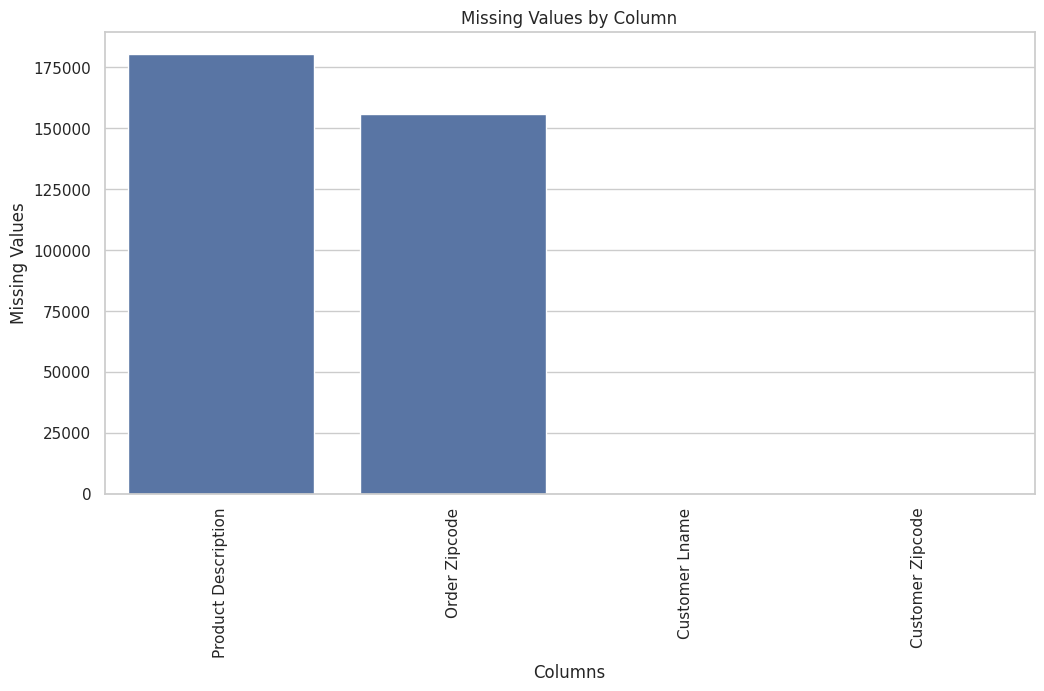

In [16]:
plt.figure(figsize=(12,6))

missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

sns.barplot(
    x=missing.index,
    y=missing.values
)

plt.xticks(rotation=90)
plt.xlabel("Columns")
plt.ylabel("Missing Values")
plt.title("Missing Values by Column")

plt.show()

In [17]:
# ==============================
# Duplicate Rows
# ==============================

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [18]:
# Duplicate Order IDs

print(df["Order Id"].duplicated().sum())

114767


In [19]:
# Duplicate Customer IDs

print(df["Customer Id"].duplicated().sum())

159867


In [20]:
dtype = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

dtype

,Column,Data Type
0,Type,object
1,Days for shipping (real),int64
2,Days for shipment (scheduled),int64
3,Benefit per order,float64
4,Sales per customer,float64
5,Delivery Status,object
6,Late_delivery_risk,int64
7,Category Id,int64
8,Category Name,object
9,Customer City,object


In [21]:
unique = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique().values
})

unique.sort_values("Unique Values")

,Column,Unique Values
46,Product Description,0
15,Customer Password,1
50,Product Status,1
11,Customer Email,1
6,Late_delivery_risk,2
10,Customer Country,2
16,Customer Segment,3
5,Delivery Status,4
2,Days for shipment (scheduled),4
52,Shipping Mode,4


In [22]:
blank = (df.astype(str).apply(lambda x: x.str.strip()).eq("")).sum()

blank = blank[blank > 0]

blank

Series([], dtype: int64)

In [23]:
memory = df.memory_usage(deep=True).sum()/1024**2

print(f"Dataset Memory Usage : {memory:.2f} MB")

Dataset Memory Usage : 299.94 MB


##  Data Quality Summary

The data quality assessment provided valuable insights into the overall condition of the dataset before analysis.

### Key Findings

- The dataset contains **no completely duplicate rows**, indicating that each record represents a unique transaction.
- The **Product Description** column has **100% missing values** and does not contain usable information. This column will be excluded from further analysis.
- The **Order Zipcode** column has approximately **86% missing values**, making it unsuitable for meaningful analysis. It will also be removed from the analytical dataset.
- **Customer Zipcode** and **Customer Last Name** contain only a few missing values, which have minimal impact on the overall analysis.
- A large number of duplicate **Order IDs** were observed. This is expected because a single customer order may contain multiple products, resulting in multiple records with the same Order ID.
- Similarly, duplicate **Customer IDs** are expected because customers can place multiple orders over time.

Overall, the dataset is in good condition for business analysis, with the primary data quality concerns limited to a few columns containing excessive missing values.

# Data Cleaning

The following columns are removed because they either contain excessive missing values or do not contribute meaningful information for business analysis.

Removing unnecessary columns improves dataset quality, reduces memory usage, and simplifies downstream analysis.

## Removing Irrelevant Columns

Based on the data quality assessment, several columns were removed because they contained excessive missing values, constant placeholder values, or did not provide meaningful analytical information.

The removed columns include:

- Product Description (100% missing values)
- Order Zipcode (86% missing values)
- Customer Email (constant placeholder value)
- Customer Password (constant placeholder value)
- Product Status (constant value across all records)

Removing these columns simplifies the dataset and improves the efficiency of subsequent analysis.

In [24]:
# ==============================
# Remove Irrelevant Columns
# ==============================

columns_to_drop = [
    "Product Description",
    "Order Zipcode",
    "Customer Email",
    "Customer Password",
    "Product Status"
]

df.drop(columns=columns_to_drop, inplace=True)

print("Columns removed successfully.")
print(f"Updated Shape: {df.shape}")

Columns removed successfully.
Updated Shape: (180519, 48)


#  Feature Engineering

Feature engineering involves creating new variables from existing data to improve analysis and generate deeper business insights.

In this section, new features such as order year, month, quarter, day of the week, shipping duration, profit margin, sales categories, and high-value order indicators are created. These derived features enable more meaningful trend analysis, customer segmentation, and operational performance evaluation.

In [25]:
df.columns[df.columns.str.contains("Date", case=False)]

Index(['order date (DateOrders)', 'shipping date (DateOrders)'], dtype='object')

##  Date Feature Engineering

To perform time-based analysis, the order and shipping date columns are converted into the appropriate datetime format. This enables the extraction of meaningful temporal features such as year, month, quarter, weekday, and shipping duration.

In [26]:
# ==============================
# Convert Date Columns
# ==============================

df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])

df["shipping date (DateOrders)"] = pd.to_datetime(df["shipping date (DateOrders)"])

print("Date columns converted successfully.")

Date columns converted successfully.


In [27]:
# ==============================
# Create Time Features
# ==============================

df["Order Year"] = df["order date (DateOrders)"].dt.year

df["Order Month"] = df["order date (DateOrders)"].dt.month

df["Order Month Name"] = df["order date (DateOrders)"].dt.month_name()

df["Order Quarter"] = df["order date (DateOrders)"].dt.quarter

df["Order Day"] = df["order date (DateOrders)"].dt.day

df["Order Day Name"] = df["order date (DateOrders)"].dt.day_name()

print("Time features created successfully.")

Time features created successfully.


## Shipping Duration

Shipping duration is calculated as the difference between shipping date and order date.

This feature provides a standardized measure of delivery time.

In [28]:
# ==============================
# Shipping Duration
# ==============================

df["Shipping Duration"] = (
    df["shipping date (DateOrders)"] -
    df["order date (DateOrders)"]
).dt.days

df["Shipping Duration"].describe()

count   180519.00
mean         3.47
std          1.67
min          0.00
25%          2.00
50%          3.00
75%          5.00
max          6.00
Name: Shipping Duration, dtype: float64

## Weekend Orders

Orders placed on weekends often exhibit different purchasing patterns compared to weekdays. This feature helps analyze customer buying behavior across the week.

In [29]:
# ==============================
# Weekend Orders
# ==============================

df["Weekend Order"] = df["Order Day Name"].isin(
    ["Saturday", "Sunday"]
)

df["Weekend Order"] = df["Weekend Order"].map({
    True: "Yes",
    False: "No"
})

df["Weekend Order"].value_counts()

Weekend Order
No     128672
Yes     51847
Name: count, dtype: int64

In [30]:
df.columns[df.columns.str.contains("Sales", case=False)]

Index(['Sales per customer', 'Sales'], dtype='object')

In [31]:
df.columns[df.columns.str.contains("Profit", case=False)]

Index(['Order Item Profit Ratio', 'Order Profit Per Order'], dtype='object')

## High Value Order

Orders are classified into high-value and regular orders based on the median sales value. Using the median instead of a fixed threshold provides a balanced segmentation and reduces the influence of extreme values.

In [32]:
# ==============================
# High Value Order
# ==============================

sales_median = df["Sales"].median()

df["High Value Order"] = np.where(
    df["Sales"] >= sales_median,
    "High",
    "Regular"
)

df["High Value Order"].value_counts()

High Value Order
High       91867
Regular    88652
Name: count, dtype: int64

## Sales Category

Sales values are grouped into Low, Medium, and High categories based on quartiles.

This simplifies sales comparisons and enables category-level analysis.

In [33]:
# ==============================
# Sales Category
# ==============================

df["Sales Category"] = pd.qcut(
    df["Sales"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df["Sales Category"].value_counts()

Sales Category
Low       70680
High      57209
Medium    52630
Name: count, dtype: int64

## Profit Category

Profit values are categorized into Loss, Low Profit, Medium Profit, and High Profit.

This helps identify profitable and loss-making transactions.

In [34]:
# ==============================
# Profit Category
# ==============================

df["Profit Category"] = np.where(
    df["Order Profit Per Order"] >= 0,
    "Profit",
    "Loss"
)

df["Profit Category"].value_counts()

Profit Category
Profit    146735
Loss       33784
Name: count, dtype: int64

## Profit Margin Percentage

Profit margin measures how much profit is earned from each dollar of sales.

It is an important business metric for evaluating operational efficiency and pricing strategy.

In [35]:
# ==============================
# Profit Margin Percentage
# ==============================

df["Profit Margin (%)"] = (
    df["Order Item Profit Ratio"] * 100
).round(2)

df["Profit Margin (%)"].describe()

count   180519.00
mean        12.06
std         46.68
min       -275.00
25%          8.00
50%         27.00
75%         36.00
max         50.00
Name: Profit Margin (%), dtype: float64

## Shipping Performance

Shipping performance classifies orders as **On Time** or **Delayed** based on shipping duration.

This engineered feature will later be compared with the original **Delivery Status** column to evaluate delivery performance.

In [36]:
# ==============================
# Shipping Performance
# ==============================

df["Shipping Performance"] = np.where(
    df["Shipping Duration"] <= 3,
    "On Time",
    "Delayed"
)

df["Shipping Performance"].value_counts()

Shipping Performance
On Time    95120
Delayed    85399
Name: count, dtype: int64

In [37]:
# ==============================
# Newly Created Features
# ==============================

new_features = [
    "Order Year",
    "Order Month",
    "Order Month Name",
    "Order Quarter",
    "Order Day",
    "Order Day Name",
    "Shipping Duration",
    "Weekend Order",
    "High Value Order",
    "Sales Category",
    "Profit Category",
    "Profit Margin (%)",
    "Shipping Performance"
]

df[new_features].head()

,Order Year,Order Month,Order Month Name,Order Quarter,Order Day,Order Day Name,Shipping Duration,Weekend Order,High Value Order,Sales Category,Profit Category,Profit Margin (%),Shipping Performance
0,2018,1,January,1,31,Wednesday,3,No,High,High,Profit,29.00,On Time
1,2018,1,January,1,13,Saturday,5,Yes,High,High,Loss,-80.00,Delayed
2,2018,1,January,1,13,Saturday,4,Yes,High,High,Loss,-80.00,Delayed
3,2018,1,January,1,13,Saturday,3,Yes,High,High,Profit,8.00,On Time
4,2018,1,January,1,13,Saturday,2,Yes,High,High,Profit,45.00,On Time


## Feature Engineering Summary

### Features Created

- Order Year
- Order Month
- Order Quarter
- Order Day
- Weekend Order
- High Value Order
- Sales Category
- Profit Category
- Profit Margin (%)
- Shipping Duration
- Shipping Performance

These engineered features enrich the dataset and support more comprehensive business analysis in the following exploratory data analysis section.

# Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps uncover patterns, relationships, trends, and anomalies within the supply chain data.

The analysis is organized into the following sections:

- Sales Analysis
- Product Analysis
- Geographic Analysis
- Customer Analysis
- Logistics Analysis
- Fraud Analysis
- Relationship Analysis

Each visualization is followed by business insights and recommendations to support data-driven decision-making.

# Sales Analysis

Sales performance is one of the most important indicators of business health.

This section explores sales distribution, profitability, seasonal trends, and the relationship between sales and profit to identify opportunities for business improvement.

## 1. Sales Distribution

### Business Question

How are customer sales distributed across all transactions?

Understanding the distribution of sales helps identify whether the business relies on many low-value orders or a smaller number of high-value purchases.

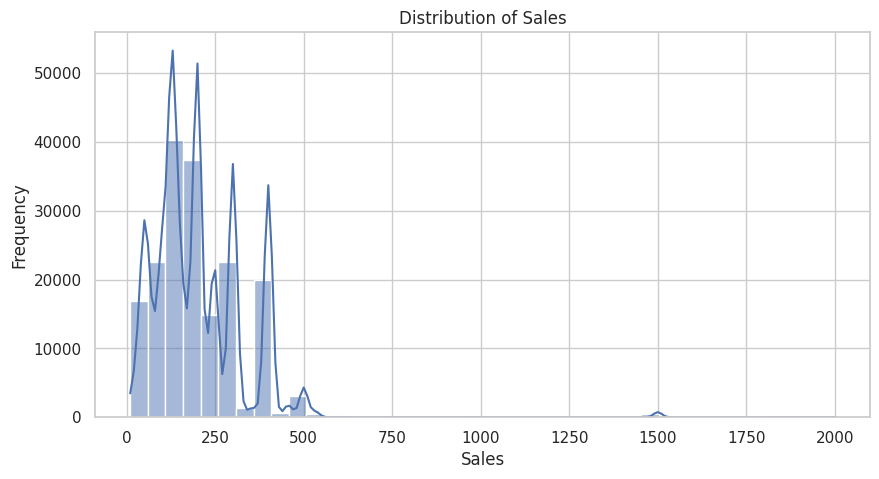

In [38]:
# ==============================
# Sales Distribution
# ==============================

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Sales",
    bins=40,
    kde=True
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

### Business Insights

- Most customer orders fall within the low-to-medium sales range.
- The distribution is positively skewed, indicating a small number of very high-value orders.
- High-value purchases contribute significantly to total revenue despite representing fewer transactions.

### Business Recommendation

Develop premium product strategies and personalized offers for customers placing high-value orders while maintaining competitive pricing for regular customers.

## 2. Profit Distribution

### Business Question

How profitable are customer orders across the business?

Analyzing profit distribution helps identify whether the company consistently generates profit or experiences frequent loss-making transactions.

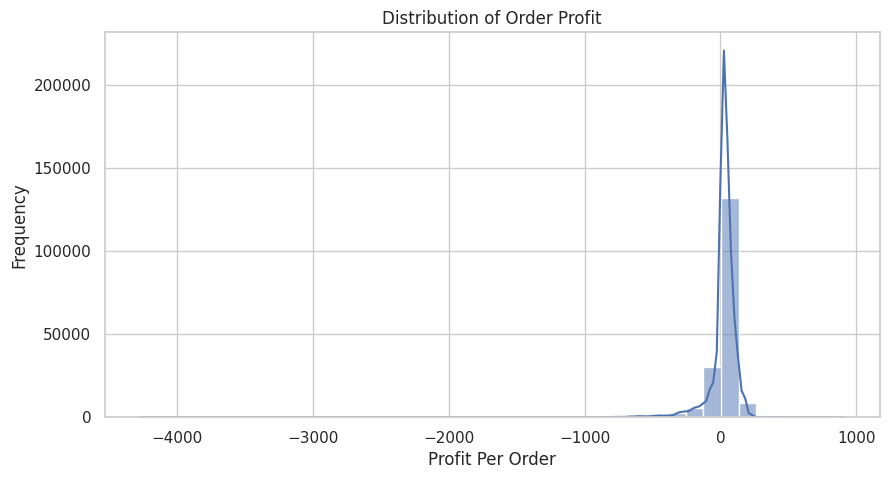

In [39]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Order Profit Per Order",
    bins=40,
    kde=True
)

plt.title("Distribution of Order Profit")
plt.xlabel("Profit Per Order")
plt.ylabel("Frequency")

plt.show()

### Business Insights

- Most transactions generate positive profits, indicating healthy overall business performance.
- A noticeable number of orders result in financial losses, suggesting opportunities for pricing or operational improvements.
- Profitability varies considerably across transactions, highlighting differences in product margins and discount strategies.

### Business Recommendation

Investigate recurring loss-making orders and review pricing, shipping costs, and promotional discounts to improve overall profitability.

## 3. Monthly Sales Trend

### Business Question

How do sales vary throughout the year?

Monthly trend analysis helps identify seasonal demand patterns and supports inventory planning and marketing strategies.

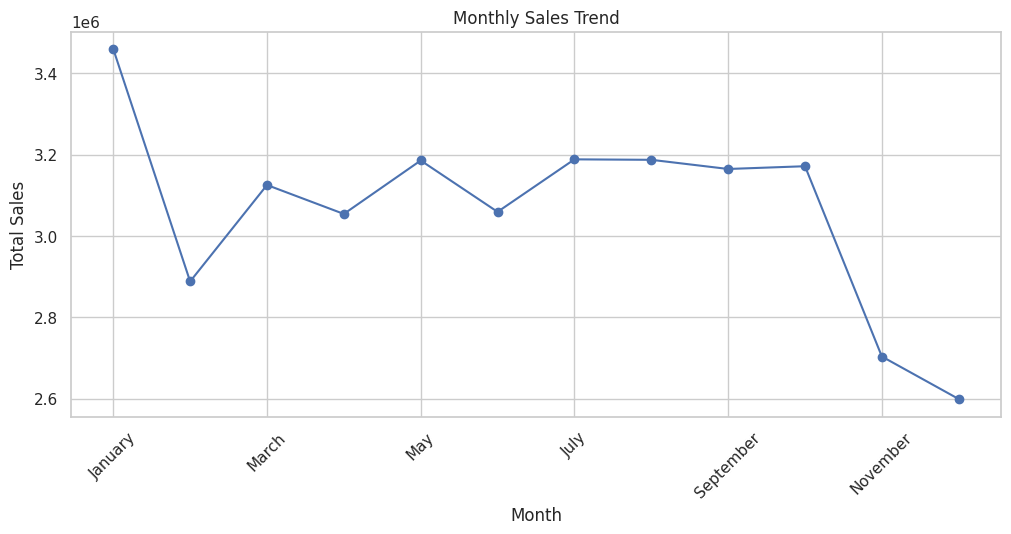

In [40]:
monthly_sales = (
    df.groupby("Order Month Name")["Sales"]
      .sum()
      .reindex([
          "January","February","March","April",
          "May","June","July","August",
          "September","October","November","December"
      ])
)

plt.figure(figsize=(12,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

### Business Insights

- Sales exhibit seasonal fluctuations rather than remaining constant throughout the year.
- Peak sales months indicate periods of increased customer demand and purchasing activity.
- Lower sales months provide opportunities for targeted promotions and demand-generation campaigns.

### Business Recommendation

Align inventory planning, staffing, and marketing campaigns with seasonal sales patterns to improve operational efficiency and customer satisfaction.

## 4. Year-wise Sales Trend

### Business Question

How has overall business sales changed over time?

Yearly sales trends provide a high-level view of business performance and long-term growth.

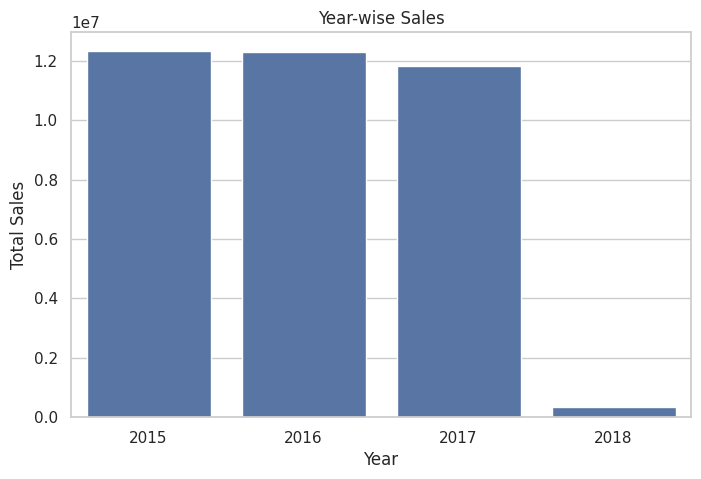

In [41]:
year_sales = (
    df.groupby("Order Year")["Sales"]
    .sum()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=year_sales.index,
    y=year_sales.values
)

plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

### Business Insights

- Sales remain relatively stable across the available years, indicating consistent business performance.
- Any sharp decline in the final year should be interpreted carefully, as it may reflect incomplete data rather than a true decrease in sales.
- Stable annual sales suggest that the business maintains a consistent customer base and operational capacity.

### Business Recommendation

Complement annual analysis with monthly and quarterly trends to better understand changes in business performance and identify growth opportunities.

## 5. Sales vs Profit Relationship

### Business Question

Does higher sales revenue always result in higher profit?

Understanding the relationship between sales and profit helps evaluate pricing effectiveness and identify high-revenue but low-profit transactions.

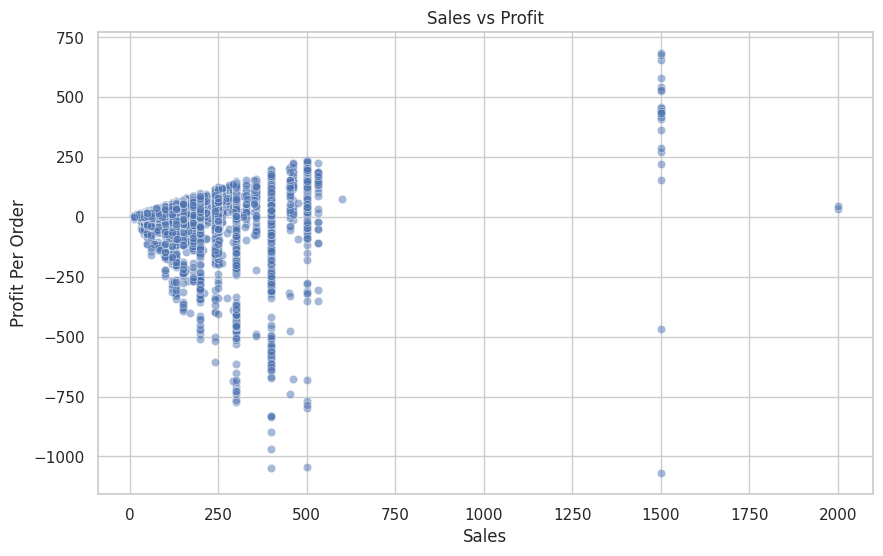

In [42]:
# ==============================
# Sales vs Profit
# ==============================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(10000, random_state=42),
    x="Sales",
    y="Order Profit Per Order",
    alpha=0.5
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit Per Order")

plt.show()

### Business Insights

- Higher sales generally lead to higher profits, but the relationship is not perfectly linear.
- Some high-sales transactions generate relatively low or even negative profits, indicating possible pricing, discounting, or cost issues.
- The wide spread of profit values suggests that profitability depends on factors beyond sales volume alone.

### Business Recommendation

Review products or orders with high sales but low profitability to optimize pricing strategies, reduce costs, and improve profit margins.

## Sales Analysis Summary

### Key Findings

- Sales are concentrated in low-to-medium value transactions.
- The business is generally profitable, although some orders generate losses.
- Sales demonstrate seasonal fluctuations throughout the year.
- Annual sales remain relatively stable across the available time period.
- Higher sales do not always translate into higher profits, emphasizing the importance of profit-focused decision-making.

In [43]:
df.columns[df.columns.str.contains("Category", case=False)]

Index(['Category Id', 'Category Name', 'Product Category Id', 'Sales Category',
       'Profit Category'],
      dtype='object')

# Product Analysis

Products and categories are the primary drivers of business revenue. This section identifies the highest-performing products, product categories, and departments to understand where the business generates the most value.

## 6. Top 10 Product Categories by Sales

### Business Question

Which product categories generate the highest sales revenue?

Identifying the best-performing categories helps businesses prioritize inventory, marketing investments, and product assortment strategies.

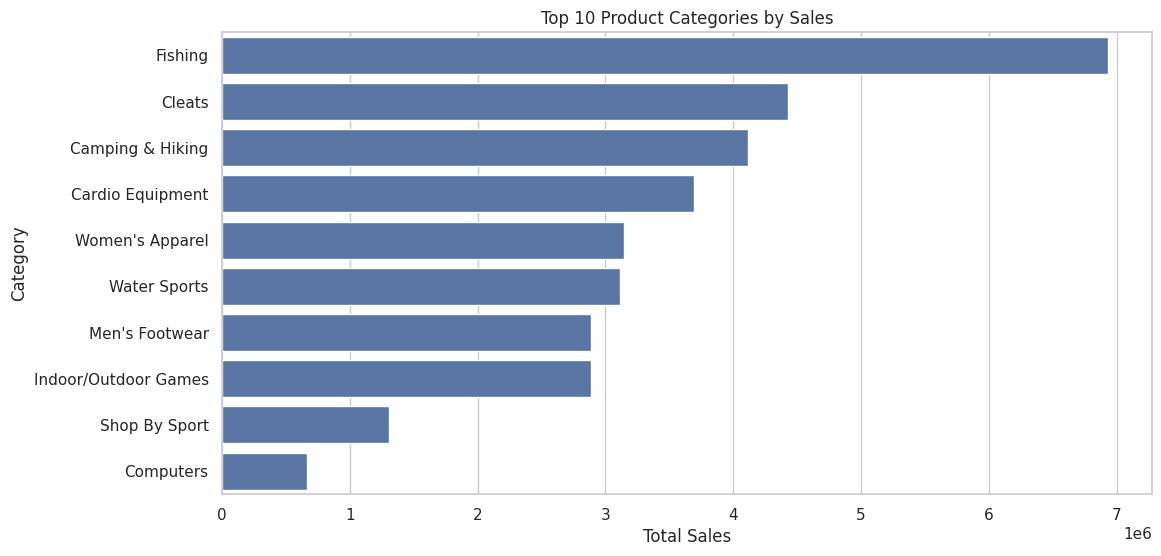

In [44]:
# ==============================
# Top 10 Product Categories by Sales
# ==============================

category_sales = (
    df.groupby("Category Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Top 10 Product Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Category")

plt.show()

### Business Insights

- A small number of product categories contribute a significant share of total sales.
- The highest-performing category represents a key revenue driver and should remain a strategic business priority.
- Lower-performing categories may require assortment optimization, targeted promotions, or pricing adjustments to improve performance.

### Business Recommendation

Maintain strong inventory availability for top-selling categories while evaluating low-performing categories for promotional campaigns or product portfolio optimization.

In [45]:
important_keywords = [
    "Product",
    "Category",
    "Department",
    "Market",
    "Region",
    "Country",
    "Customer",
    "Shipping",
    "Delivery",
    "Order Status",
    "Type"
]

for keyword in important_keywords:
    print(f"\n----- {keyword} -----")
    print(df.columns[df.columns.str.contains(keyword, case=False)].tolist())


----- Product -----
['Order Item Product Price', 'Product Card Id', 'Product Category Id', 'Product Image', 'Product Name', 'Product Price']

----- Category -----
['Category Id', 'Category Name', 'Product Category Id', 'Sales Category', 'Profit Category']

----- Department -----
['Department Id', 'Department Name']

----- Market -----
['Market']

----- Region -----
['Order Region']

----- Country -----
['Customer Country', 'Order Country']

----- Customer -----
['Sales per customer', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Order Customer Id']

----- Shipping -----
['Days for shipping (real)', 'shipping date (DateOrders)', 'Shipping Mode', 'Shipping Duration', 'Shipping Performance']

----- Delivery -----
['Delivery Status', 'Late_delivery_risk']

----- Order Status -----
['Order Status']

----- Type -----
['Type']


## 7. Top 10 Products by Sales

### Business Question

Which individual products generate the highest sales revenue?

Understanding top-selling products helps optimize inventory management, supplier planning, and marketing efforts.

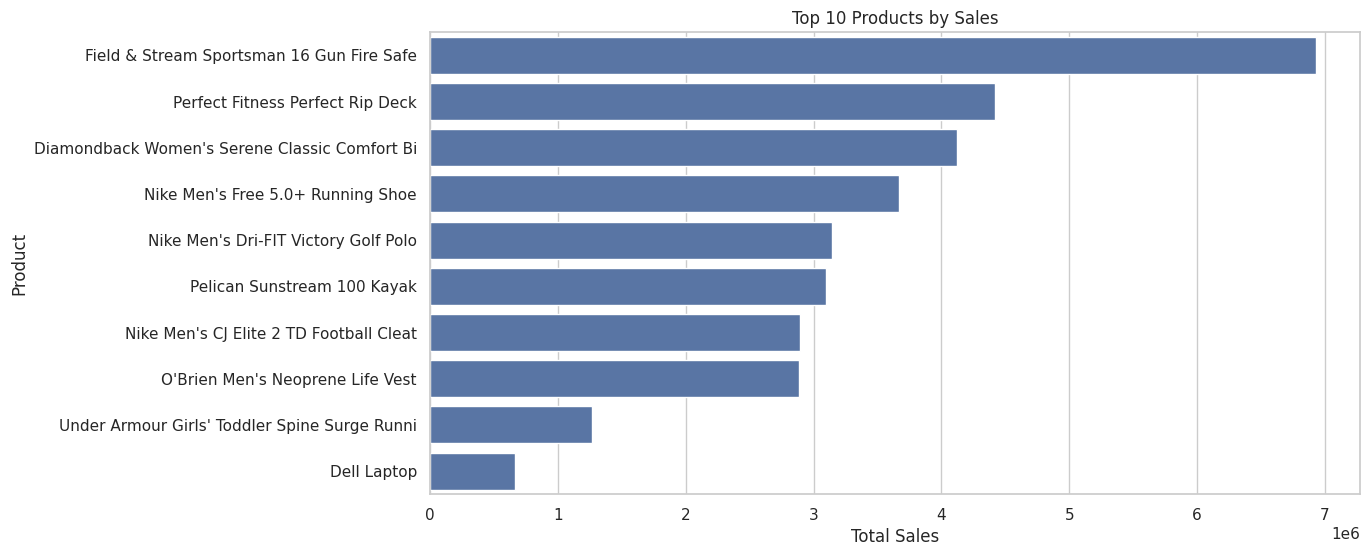

In [46]:
# ==============================
# Top 10 Products by Sales
# ==============================

top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.show()

### Business Insights

- Revenue is concentrated among a relatively small number of products.
- Best-selling products should be prioritized for inventory planning to prevent stock shortages.
- Lower-selling products may require marketing support or product portfolio evaluation.

### Business Recommendation

Implement inventory forecasting for top-selling products and periodically review underperforming products to improve overall product profitability.

## 8. Sales by Department

### Business Question

Which departments contribute the most to total business revenue?

Department-level analysis helps identify business units that have the greatest impact on overall sales.

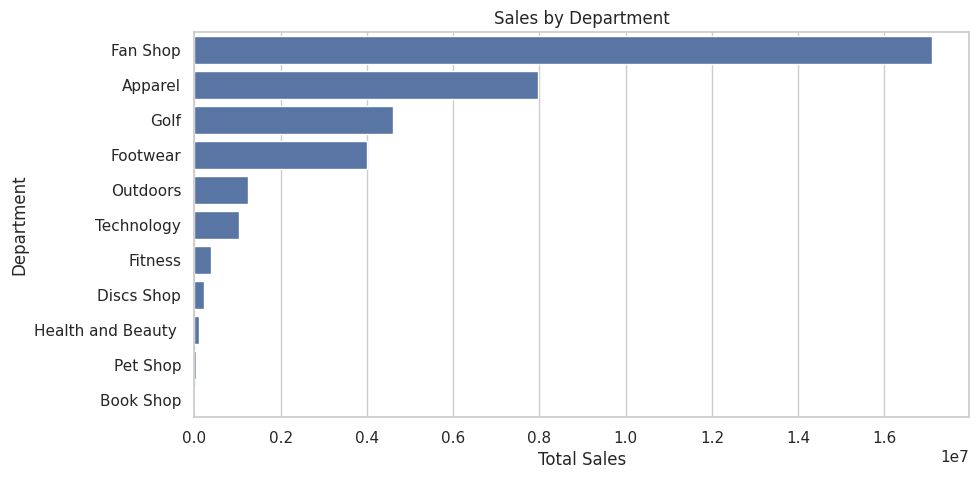

In [47]:
# ==============================
# Sales by Department
# ==============================

department_sales = (
    df.groupby("Department Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=department_sales.values,
    y=department_sales.index
)

plt.title("Sales by Department")
plt.xlabel("Total Sales")
plt.ylabel("Department")

plt.show()

### Business Insights

- Revenue is unevenly distributed across departments.
- The leading department contributes a substantial portion of total sales.
- Departments with lower revenue may benefit from additional promotional efforts or product expansion.

### Business Recommendation

Continue investing in high-performing departments while analyzing customer demand and profitability within lower-performing departments.

# Geographic Analysis

Understanding geographical performance helps businesses identify high-performing markets and regions while uncovering opportunities for future expansion.

## 9. Sales by Market

### Business Question

Which global markets contribute the most to business revenue?

Market-level analysis supports strategic expansion, resource allocation, and regional sales planning.

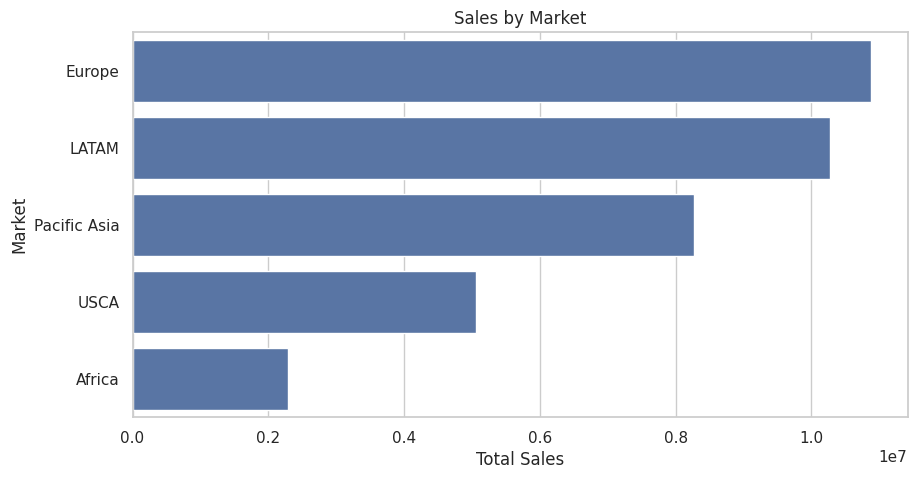

In [48]:
# ==============================
# Sales by Market
# ==============================

market_sales = (
    df.groupby("Market")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=market_sales.values,
    y=market_sales.index
)

plt.title("Sales by Market")
plt.xlabel("Total Sales")
plt.ylabel("Market")

plt.show()

### Business Insights

- Business performance varies significantly across different markets.
- High-performing markets contribute the largest share of total revenue.
- Lower-performing markets may represent opportunities for future expansion or localized marketing initiatives.

### Business Recommendation

Allocate resources strategically by strengthening operations in high-performing markets while developing growth strategies for emerging markets.

## 10. Top 10 Order Regions by Sales

### Business Question

Which regions generate the highest sales?

Regional analysis helps identify areas with the greatest customer demand and supports regional sales planning.

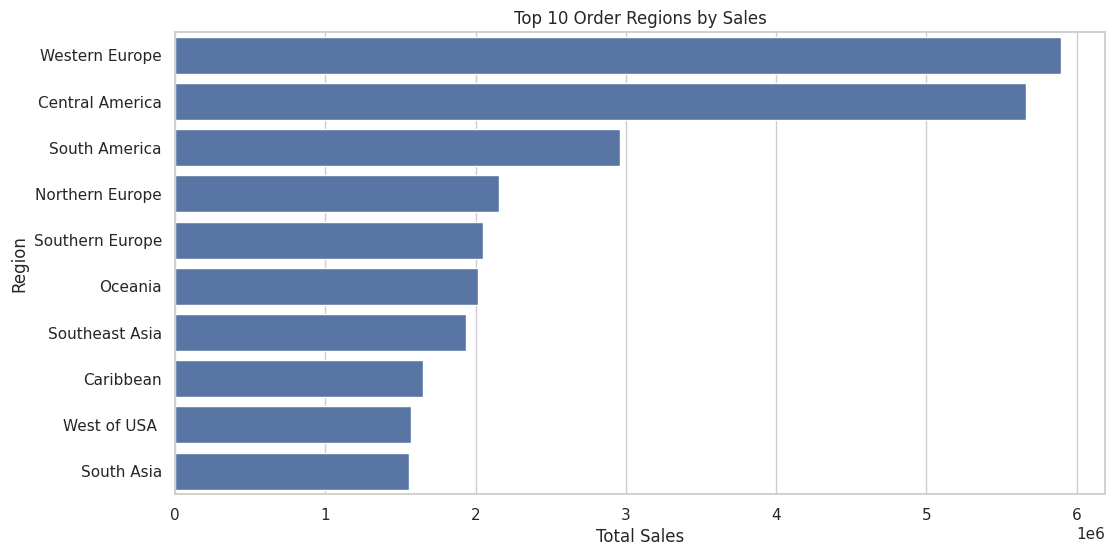

In [49]:
# ==============================
# Top 10 Order Regions by Sales
# ==============================

region_sales = (
    df.groupby("Order Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=region_sales.values,
    y=region_sales.index
)

plt.title("Top 10 Order Regions by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Region")

plt.show()

### Business Insights

- Sales are concentrated within a limited number of regions.
- High-performing regions should be prioritized for customer retention and inventory planning.
- Lower-performing regions may require targeted sales initiatives and localized marketing campaigns.

### Business Recommendation

Develop region-specific business strategies by combining regional sales performance with customer demand and logistics efficiency.

## 11. Top 10 Countries by Sales

### Business Question

Which countries contribute the highest revenue?

Country-level analysis provides insights into international business performance and helps prioritize strategic markets.

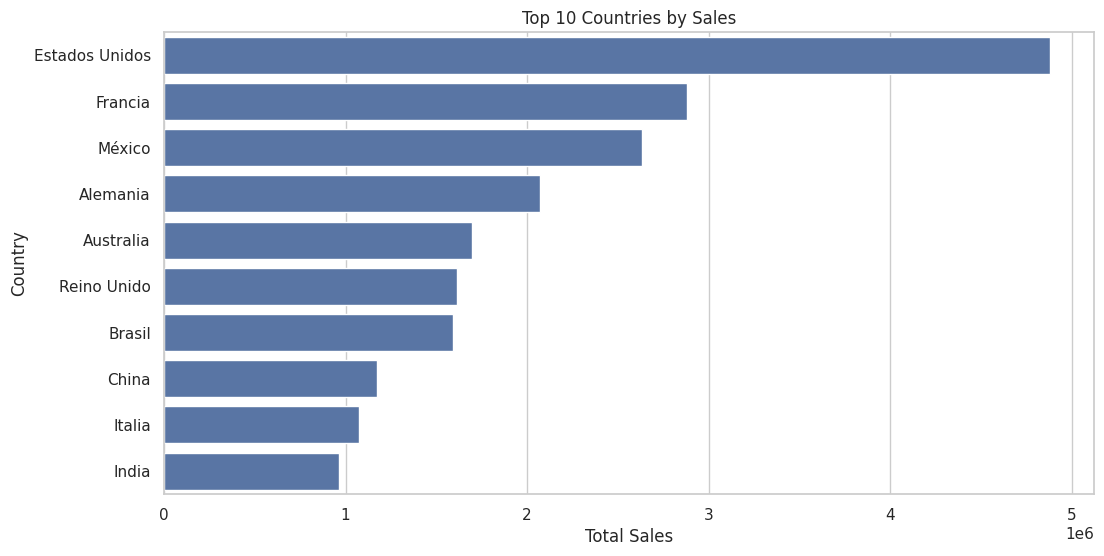

In [50]:
# ==============================
# Top 10 Countries by Sales
# ==============================

country_sales = (
    df.groupby("Order Country")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_sales.values,
    y=country_sales.index
)

plt.title("Top 10 Countries by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")

plt.show()

### Business Insights

- A small group of countries accounts for a significant proportion of total sales.
- Strong-performing countries represent strategic markets for continued investment and customer retention.
- Lower-ranked countries may offer growth opportunities through targeted marketing and localized product strategies.

### Business Recommendation

Prioritize investment in top-performing countries while evaluating customer preferences and operational challenges in developing markets.

## Product & Geographic Analysis Summary

### Key Findings

- Sales are concentrated within a limited number of product categories and best-selling products.
- Certain departments contribute disproportionately to overall revenue.
- Revenue varies significantly across global markets, regions, and countries.
- Geographic analysis highlights opportunities to strengthen operations in established markets while expanding into lower-performing regions.
- Product and regional insights provide a strong foundation for inventory planning, sales forecasting, and strategic decision-making.

# Customer Analysis

Understanding customer behavior helps businesses identify their most valuable customer segments and optimize marketing, retention, and sales strategies.

## 12. Sales by Customer Segment

### Business Question

Which customer segment contributes the highest sales?

Customer segmentation helps identify the most valuable customer groups and supports targeted marketing and customer retention strategies.

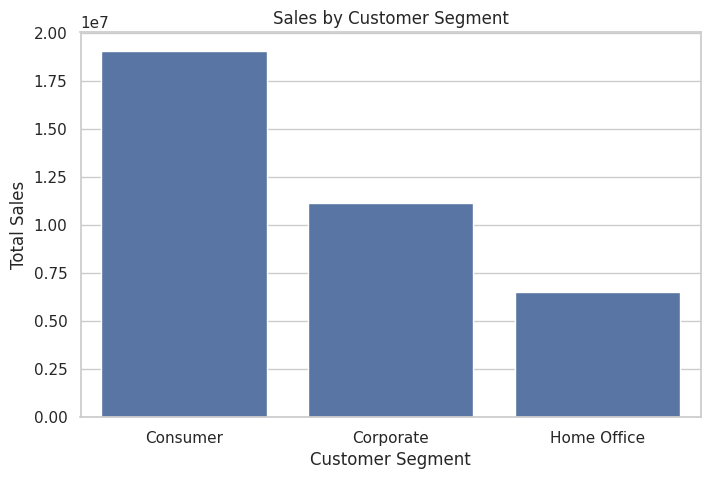

In [51]:
# ==============================
# Sales by Customer Segment
# ==============================

segment_sales = (
    df.groupby("Customer Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.show()

### Business Insights

- Customer segments contribute differently to total revenue.
- The leading customer segment represents the largest revenue opportunity for the business.
- Lower-performing segments may require targeted marketing campaigns and customer engagement initiatives.

### Business Recommendation

Develop personalized marketing strategies for each customer segment while strengthening customer retention efforts for the highest-value segment.

## 13. Top 10 Customers by Sales

### Business Question

Who are the highest-value customers?

Identifying top customers helps businesses prioritize relationship management and loyalty initiatives.

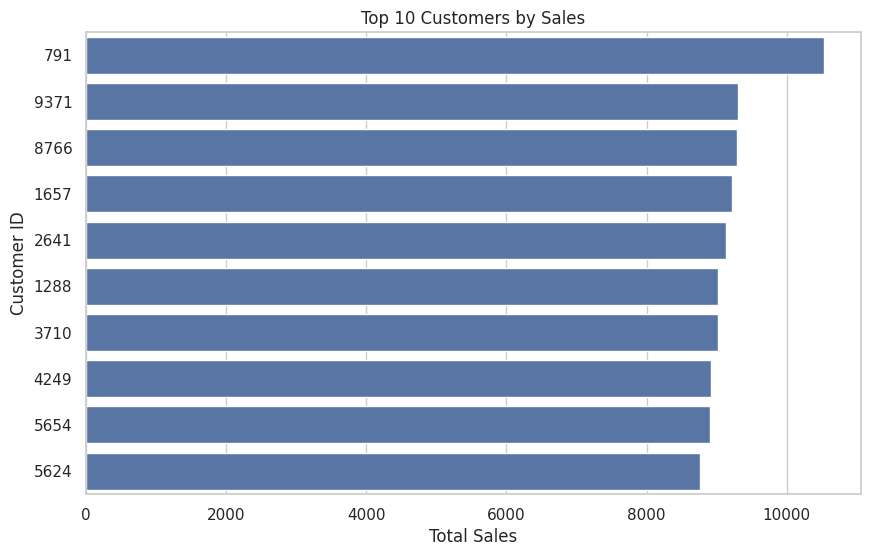

In [52]:
# ==============================
# Top Customers by Sales
# ==============================

top_customers = (
    df.groupby("Customer Id")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index.astype(str)
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer ID")

plt.show()

### Business Insights

- A relatively small number of customers contribute a disproportionately high share of revenue.
- These customers are valuable assets and should receive priority attention.
- Customer concentration suggests opportunities for loyalty programs and personalized services.

### Business Recommendation

Introduce customer loyalty programs, personalized recommendations, and exclusive offers to retain high-value customers and increase customer lifetime value.

# Logistics Analysis

Efficient logistics operations improve customer satisfaction and reduce operational costs.

This section evaluates shipping methods, delivery performance, shipping duration, and delivery risks.

## 14. Shipping Mode Analysis

### Business Question

Which shipping methods are most frequently used?

Shipping mode analysis helps understand customer delivery preferences and operational workload.

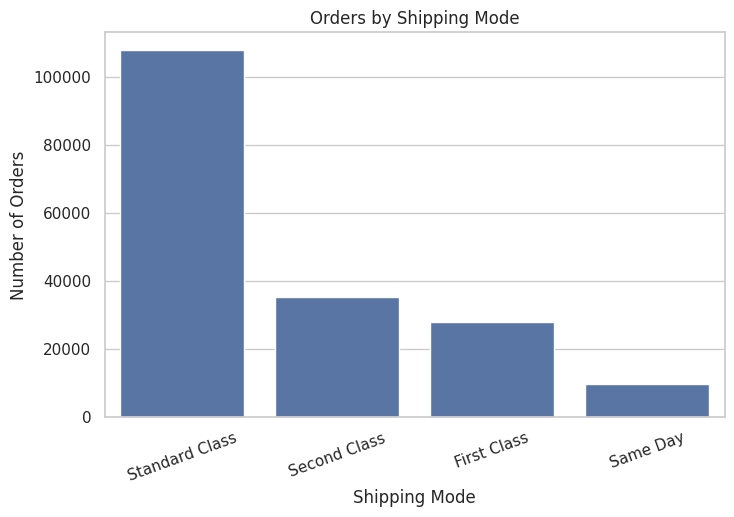

In [53]:
# ==============================
# Shipping Mode Analysis
# ==============================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Shipping Mode",
    order=df["Shipping Mode"].value_counts().index
)

plt.title("Orders by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Orders")

plt.xticks(rotation=20)

plt.show()

### Business Insights

- Standard shipping is the most frequently selected delivery option.
- Premium shipping methods are used less frequently, indicating customer preference for cost-effective delivery.
- Shipping demand is concentrated in a limited number of delivery methods.

### Business Recommendation

Optimize operations for the most frequently used shipping mode while evaluating opportunities to promote faster delivery services where appropriate.

## 15. Delivery Status Analysis

### Business Question

What is the distribution of delivery outcomes?

Analyzing delivery status helps evaluate operational performance and customer service quality.

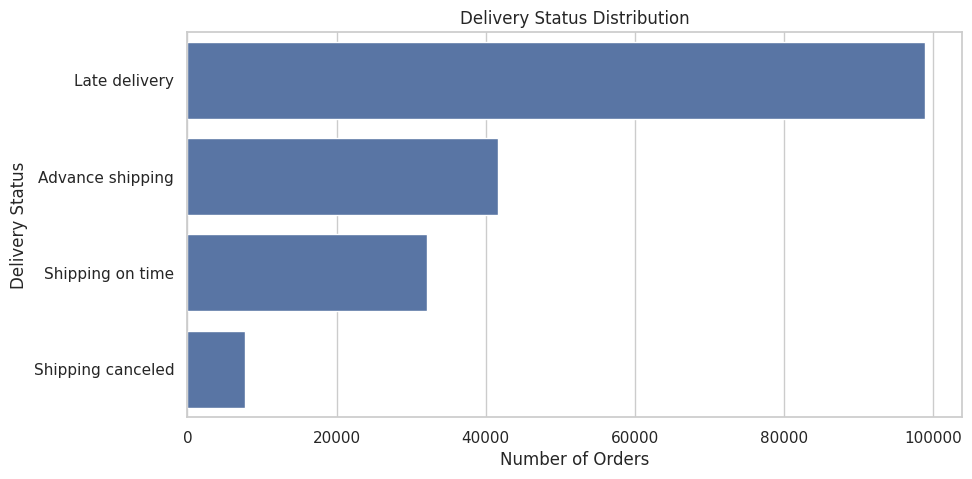

In [54]:
# ==============================
# Delivery Status Analysis
# ==============================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="Delivery Status",
    order=df["Delivery Status"].value_counts().index
)

plt.title("Delivery Status Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Delivery Status")

plt.show()

### Business Insights

- Most orders are delivered successfully, indicating stable logistics operations.
- Late deliveries remain a significant operational challenge.
- Canceled or exceptional delivery outcomes occur less frequently but should still be monitored.

### Business Recommendation

Focus on reducing late deliveries through improved route planning, warehouse coordination, and proactive shipment tracking.

## 16. Shipping Performance Analysis

### Business Question

How does the engineered Shipping Performance compare across all orders?

This analysis evaluates the custom shipping performance feature created using shipping duration.

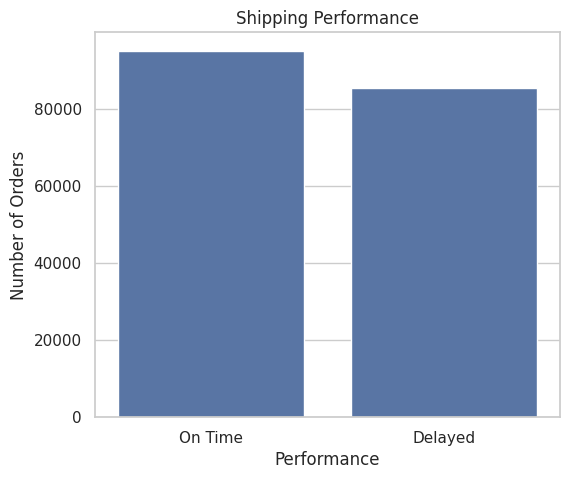

In [55]:
# ==============================
# Shipping Performance Analysis
# ==============================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Shipping Performance"
)

plt.title("Shipping Performance")
plt.xlabel("Performance")
plt.ylabel("Number of Orders")

plt.show()

### Business Insights

- The engineered shipping performance metric separates orders into on-time and delayed deliveries.
- Delayed shipments represent opportunities for operational improvements.
- This derived feature provides a simplified measure of delivery efficiency.

### Business Recommendation

Monitor delayed shipments regularly and identify operational bottlenecks contributing to delivery delays.

## 17. Shipping Performance vs Delivery Status

### Business Question

Does the engineered shipping performance align with the recorded delivery status?

Comparing these variables validates the engineered feature and helps identify inconsistencies in delivery operations.

In [56]:
# ==============================
# Shipping Performance vs Delivery Status
# ==============================

comparison = pd.crosstab(
    df["Shipping Performance"],
    df["Delivery Status"]
)

comparison

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Shipping Performance,,,,
Delayed,0,61251,3610,20538
On Time,41592,37726,4144,11658


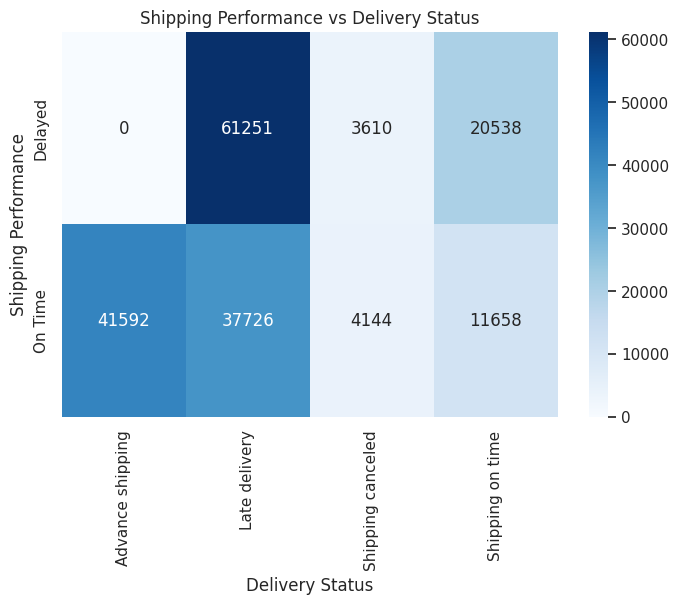

In [57]:
plt.figure(figsize=(8,5))

sns.heatmap(
    comparison,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Shipping Performance vs Delivery Status")

plt.show()

### Business Insights

- The engineered shipping performance generally aligns with the recorded delivery status.
- Any mismatches indicate differences between calculated shipping duration and operational delivery outcomes.
- Comparing engineered and original variables increases confidence in the feature engineering process.

### Business Recommendation

Use both engineered metrics and operational delivery labels together for more accurate logistics performance monitoring.

## 18. Late Delivery Risk Analysis

### Business Question

How common is late delivery risk?

Understanding late delivery risk helps businesses improve customer satisfaction and logistics planning.

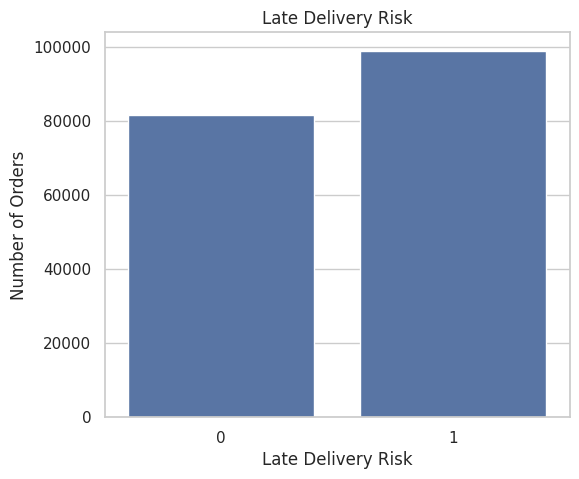

In [58]:
# ==============================
# Late Delivery Risk Analysis
# ==============================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Late_delivery_risk"
)

plt.title("Late Delivery Risk")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Number of Orders")

plt.show()

### Business Insights

- A significant proportion of orders are associated with late delivery risk.
- Reducing late delivery risk can improve customer satisfaction and operational reliability.
- Monitoring this indicator helps prioritize logistics improvements.

### Business Recommendation

Develop predictive monitoring systems for high-risk shipments and implement proactive interventions before delays occur.

## Customer & Logistics Analysis Summary

### Key Findings

- Customer revenue is concentrated among a limited number of customer segments and high-value customers.
- Standard shipping dominates customer delivery preferences.
- Delivery performance is generally stable but late deliveries remain an important operational issue.
- The engineered Shipping Performance feature aligns well with the original Delivery Status field, validating the feature engineering approach.
- Late delivery risk highlights opportunities to improve logistics efficiency and customer satisfaction.

# Fraud Analysis

Fraudulent transactions can lead to financial losses, operational disruptions, and reduced customer trust.

This section analyzes suspected fraudulent orders to identify high-risk markets, customer segments, and shipping methods that may require additional monitoring and preventive measures.

## 19. Order Status Distribution

### Business Question

What is the distribution of order statuses across all transactions?

Understanding order status helps evaluate operational efficiency and identify the proportion of suspected fraudulent orders.

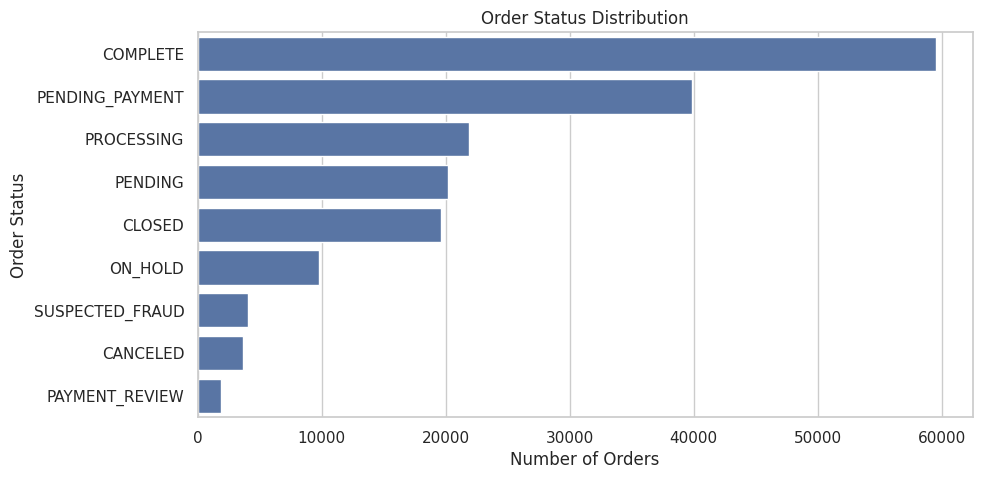

In [59]:
# ==============================
# Order Status Distribution
# ==============================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="Order Status",
    order=df["Order Status"].value_counts().index
)

plt.title("Order Status Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Order Status")

plt.show()

### Business Insights

- Completed and closed orders account for the majority of transactions, indicating stable business operations.
- Suspected fraud represents only a small proportion of orders but requires close monitoring because of its financial impact.
- Pending or canceled orders may indicate operational inefficiencies or customer-related issues.

### Business Recommendation

Implement automated monitoring for unusual order patterns and investigate high-risk order statuses to minimize operational losses.

## 20. Suspected Fraud by Market

### Business Question

Which markets experience the highest number of suspected fraudulent orders?

Market-level fraud analysis helps identify regions requiring stronger fraud prevention measures.

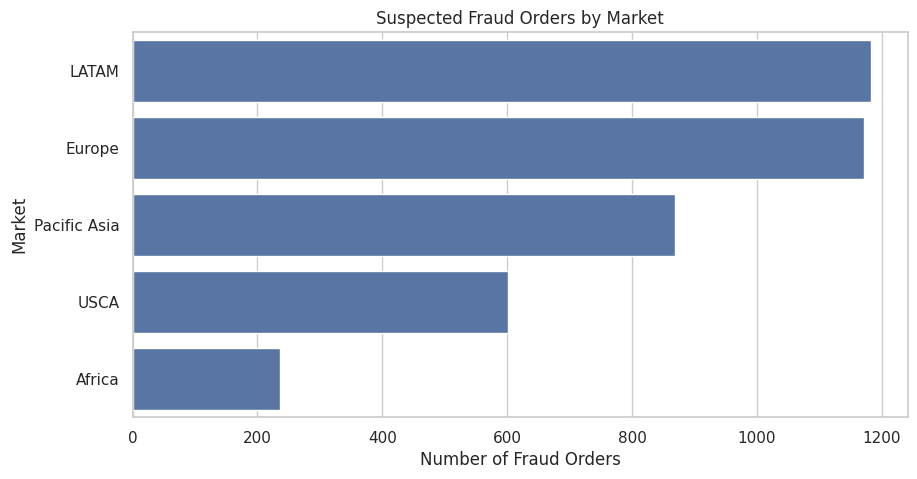

In [60]:
# ==============================
# Fraud by Market
# ==============================

fraud_market = (
    df[df["Order Status"] == "SUSPECTED_FRAUD"]
    .groupby("Market")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=fraud_market.values,
    y=fraud_market.index
)

plt.title("Suspected Fraud Orders by Market")
plt.xlabel("Number of Fraud Orders")
plt.ylabel("Market")

plt.show()

### Business Insights

- Fraud occurrences are concentrated in a limited number of markets.
- Markets with consistently higher fraud counts should receive additional monitoring and verification.
- Regional fraud trends suggest that prevention strategies should be tailored to specific markets.

### Business Recommendation

Strengthen fraud detection systems and customer verification processes in markets with higher fraud activity.

## 21. Suspected Fraud by Shipping Mode

### Business Question

Is fraud associated with specific shipping methods?

Shipping mode analysis helps determine whether certain delivery methods carry a higher fraud risk.

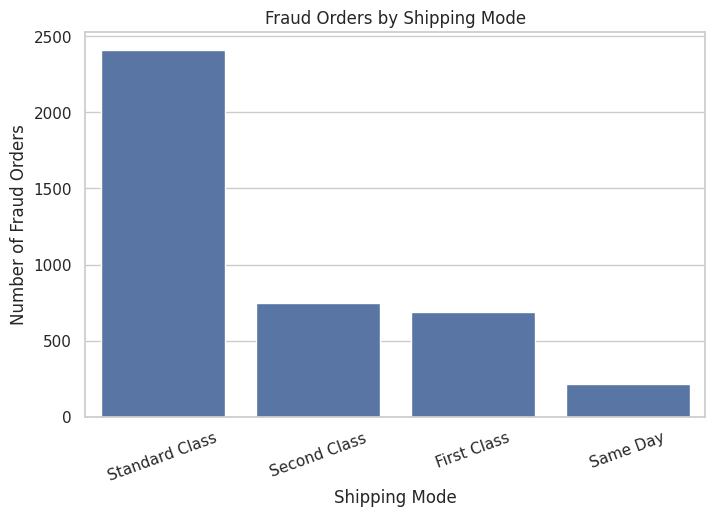

In [61]:
# ==============================
# Fraud by Shipping Mode
# ==============================

fraud_shipping = (
    df[df["Order Status"] == "SUSPECTED_FRAUD"]
    .groupby("Shipping Mode")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=fraud_shipping.index,
    y=fraud_shipping.values
)

plt.title("Fraud Orders by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Fraud Orders")

plt.xticks(rotation=20)

plt.show()

### Business Insights

- Fraud is not evenly distributed across shipping methods.
- Shipping methods with higher fraud frequency should receive additional verification.
- Delivery policies can be optimized to reduce fraud exposure.

### Business Recommendation

Introduce additional verification checks for high-risk shipping methods while maintaining a smooth experience for low-risk orders.

## 22. Suspected Fraud by Customer Segment

### Business Question

Which customer segments are associated with the highest number of suspected fraudulent orders?

Customer-level fraud analysis helps identify groups requiring enhanced verification.

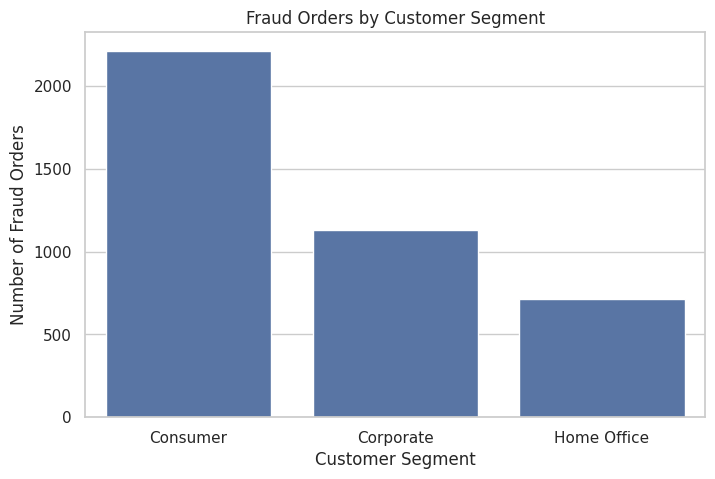

In [62]:
# ==============================
# Fraud by Customer Segment
# ==============================

fraud_segment = (
    df[df["Order Status"] == "SUSPECTED_FRAUD"]
    .groupby("Customer Segment")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=fraud_segment.index,
    y=fraud_segment.values
)

plt.title("Fraud Orders by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Fraud Orders")

plt.show()

### Business Insights

- Fraud occurrences differ across customer segments.
- High-risk customer segments may require stronger identity verification and transaction monitoring.
- Segment-level analysis enables more targeted fraud prevention strategies.

### Business Recommendation

Implement risk-based customer verification to reduce fraud while maintaining a positive customer experience.

# Relationship Analysis

Relationship analysis examines how different business variables interact with one another. Understanding these relationships helps identify the factors influencing sales, profitability, and operational performance.

## 23. Correlation Heatmap

### Business Question

Which numerical variables are most strongly related?

Correlation analysis helps identify positive and negative relationships among key business metrics.

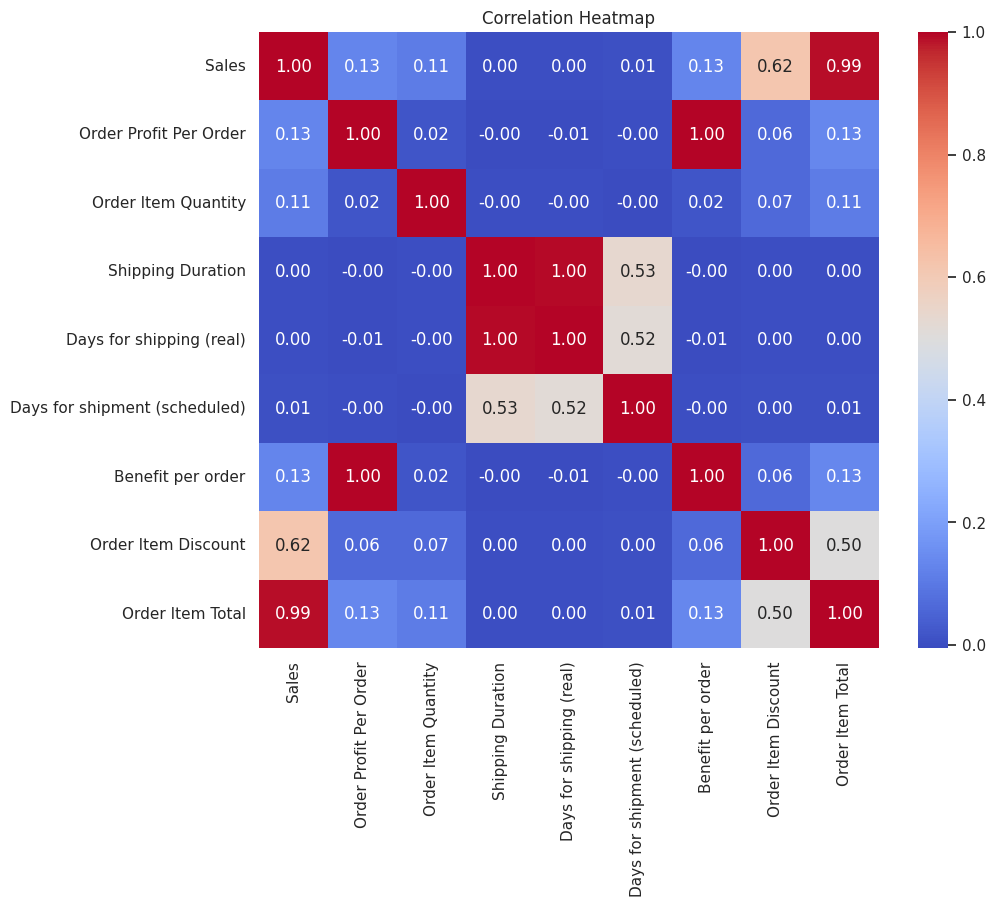

In [63]:
# ==============================
# Correlation Heatmap
# ==============================

corr_columns = [
    "Sales",
    "Order Profit Per Order",
    "Order Item Quantity",
    "Shipping Duration",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Benefit per order",
    "Order Item Discount",
    "Order Item Total"
]

corr_matrix = df[corr_columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Business Insights

- Sales show a positive relationship with profit and order totals, indicating that higher sales generally generate higher revenue.
- Shipping-related variables exhibit strong correlations, reflecting consistent logistics processes.
- Discounts and profitability should be evaluated together to balance customer acquisition with financial performance.

### Business Recommendation

Use correlation analysis to support pricing, inventory, and logistics decisions while recognizing that correlation does not imply causation.

## Fraud & Relationship Analysis Summary

### Key Findings

- Fraud cases represent a relatively small share of total transactions but should be actively monitored.
- Fraud activity varies across markets, shipping methods, and customer segments.
- Correlation analysis confirms strong relationships between sales, profit, and order value.
- Shipping metrics exhibit consistent relationships, supporting the reliability of logistics performance analysis.
- Combining fraud detection with operational analytics enables more informed business decisions.

# Key Findings

The exploratory analysis revealed several important business insights across sales, products, customers, logistics, and fraud.

## Sales

- Sales are concentrated in low-to-medium value transactions, with a smaller number of high-value orders contributing significantly to total revenue.
- Most transactions generate positive profits, although a portion of orders still operate at a loss.
- Sales exhibit seasonal variations, indicating opportunities for improved inventory planning and promotional campaigns.

---

## Products

- A limited number of product categories generate the majority of revenue.
- Top-selling products contribute disproportionately to overall business performance.
- Department-level analysis highlights where business investment should be prioritized.

---

## Geography

- Revenue is concentrated within a few major markets, regions, and countries.
- Geographic differences suggest opportunities for market-specific sales strategies and operational improvements.

---

## Customers

- Customer segments contribute differently to total revenue.
- A relatively small group of customers generates a large share of sales.
- Customer retention initiatives should focus on high-value customers.

---

## Logistics

- Standard shipping is the most commonly used shipping method.
- Late deliveries remain one of the most significant operational challenges.
- The engineered Shipping Performance feature aligns well with the dataset's Delivery Status, validating the feature engineering process.

---

## Fraud

- Suspected fraudulent orders account for only a small proportion of total transactions.
- Fraud is concentrated within specific markets, shipping methods, and customer segments.
- Continuous monitoring can help minimize operational and financial risks.

# Business Recommendations

Based on the analysis, the following recommendations can improve operational efficiency, customer satisfaction, and business performance.

## Sales

- Focus marketing campaigns on high-performing seasons.
- Increase average order value through product bundles and cross-selling.

---

## Product Strategy

- Maintain sufficient inventory for best-selling products.
- Review low-performing products for pricing, promotion, or discontinuation.

---

## Customer Strategy

- Develop loyalty programs for high-value customers.
- Personalize promotions based on customer segments.

---

## Logistics

- Reduce late deliveries through improved warehouse coordination and route optimization.
- Monitor shipping performance regularly using operational dashboards.

---

## Geographic Strategy

- Increase investment in high-performing markets.
- Develop localized marketing campaigns for underperforming regions.

---

## Fraud Prevention

- Monitor suspected fraudulent orders continuously.
- Introduce additional verification for high-risk transactions.
- Regularly review fraud trends across markets and customer segments.

# Executive Summary

This project analyzed the DataCo Smart Supply Chain dataset using an end-to-end data analytics workflow.

The process began with data understanding, followed by data quality assessment, cleaning, and feature engineering. Exploratory Data Analysis was then conducted to evaluate sales performance, profitability, customer behavior, product performance, logistics efficiency, and fraud patterns.

The analysis showed that revenue is concentrated among a limited number of products, customers, and geographic markets. While the business demonstrates healthy overall profitability, opportunities exist to reduce loss-making transactions, improve delivery performance, and strengthen fraud monitoring.

The engineered features, including Shipping Performance, Profit Category, Sales Category, High Value Order, and Profit Margin, provided additional business insights beyond the original dataset.

Overall, this project demonstrates the complete data analytics lifecycle, transforming raw transactional data into actionable business insights that support strategic decision-making.

# Conclusion

This project demonstrates a complete end-to-end data analytics workflow using a real-world supply chain dataset.

The analysis covered:

- Data Cleaning
- Data Quality Assessment
- Feature Engineering
- Exploratory Data Analysis
- Business Insights
- Business Recommendations

The findings provide valuable insights into sales trends, customer behavior, logistics performance, product performance, and fraud monitoring.

The techniques used in this notebook can be extended to larger supply chain datasets and integrated with SQL databases, Excel reports, and Power BI dashboards to support real-time business intelligence.

# Next Steps

Future improvements for this project include:

- Build an interactive Power BI dashboard using the cleaned dataset.
- Create SQL queries to answer key business questions.
- Develop KPI dashboards for executives.
- Apply predictive models for sales forecasting.
- Build machine learning models to predict late deliveries and identify potentially fraudulent orders.
- Automate the analytics pipeline for regular business reporting.

# Export Cleaned Dataset

The cleaned and feature-engineered dataset is exported for use in subsequent stages of the project.

The exported dataset will be used for:

- SQL Analysis
- Power BI Dashboard Development
- Business Reporting
- Further Analytics

In [64]:
# ==============================
# Export Cleaned Dataset
# ==============================

output_file = "DataCo_Cleaned_Supply_Chain.csv"

df.to_csv(output_file, index=False)

print(f"Dataset exported successfully as '{output_file}'")
print(f"Final Dataset Shape: {df.shape}")

Dataset exported successfully as 'DataCo_Cleaned_Supply_Chain.csv'
Final Dataset Shape: (180519, 61)
